<a href="https://colab.research.google.com/github/faysal-codes/diabetes-prediction-model/blob/main/Diabetes_Prediction_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import Library
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

**1. Data Loading & Exploration**

In [2]:
# Load and Read Dataset with Pandas
df = pd.read_csv('/content/diabetes-prediction-model/diabetes.csv')

In [3]:
# Show First Few Rows
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [4]:
# Check Dataset Shape
df.shape

(768, 9)

In [5]:
# Check Missing Values
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [6]:
# Check Basic Statistics
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
# Check Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


In [8]:
# Check Class Balance
df['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


**2. Data Preprocessing**

In [9]:
# Initialize X (Features) and y (Ground Truth)
X = df.drop('Outcome', axis = 1)
y = df['Outcome']
# Splitting Train and Test Data (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [10]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**3. Model Training**

In [11]:
# Initialize the Models
models = {
    'Logistic Regression': (LogisticRegression(max_iter = 1000, random_state = 42), X_train_scaled, X_test_scaled),
    'Decision Tree': (DecisionTreeClassifier(random_state = 42), X_train, X_test),
    'Random Forest': (RandomForestClassifier(random_state = 42), X_train, X_test),
    'SVM': (SVC(probability = True, max_iter = 1000, random_state = 42), X_train_scaled, X_test_scaled),
    'KNN': (KNeighborsClassifier(), X_train_scaled, X_test_scaled)
}

**4. Model Evaluation**

In [12]:
# Models Predictions
results = {}
for name, (model, X_tr, X_te) in models.items():
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    y_pred_proba = model.predict_proba(X_te)[:, 1]
# Print Models Predictions
    print(f'===== {name} =====')
    print(f'Accuracy: {accuracy_score(y_test, y_pred):.3f}')
    print(f'Precision: {precision_score(y_test, y_pred):.3f}')
    print(f'Recall: {recall_score(y_test, y_pred):.3f}')
    print(f'F1 Score: {f1_score(y_test, y_pred):.3f}')
    print(f'ROC AUC Score: {roc_auc_score(y_test, y_pred_proba):.3f}\n')
    results[name] = {'model': model, 'y_pred': y_pred, 'y_proba': y_pred_proba}

===== Logistic Regression =====
Accuracy: 0.773
Precision: 0.692
Recall: 0.655
F1 Score: 0.673
ROC AUC Score: 0.844

===== Decision Tree =====
Accuracy: 0.838
Precision: 0.750
Recall: 0.818
F1 Score: 0.783
ROC AUC Score: 0.833

===== Random Forest =====
Accuracy: 0.883
Precision: 0.814
Recall: 0.873
F1 Score: 0.842
ROC AUC Score: 0.933

===== SVM =====
Accuracy: 0.825
Precision: 0.759
Recall: 0.745
F1 Score: 0.752
ROC AUC Score: 0.885

===== KNN =====
Accuracy: 0.799
Precision: 0.694
Recall: 0.782
F1 Score: 0.735
ROC AUC Score: 0.826



5. Model Comparison & Best Model Selection

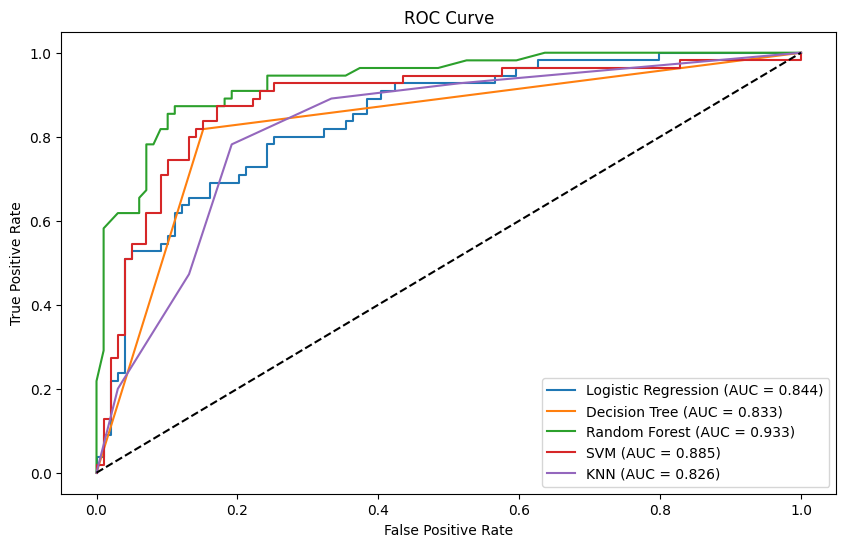

In [13]:
# Compare Model Performances using ROC Curves
plt.figure(figsize = (10, 6))
for name, result in results.items():
    fpr, tpr, thresholds = roc_curve(y_test, result['y_proba'])
    plt.plot(fpr, tpr, label = f"{name} (AUC = {roc_auc_score(y_test, result['y_proba']):.3f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [14]:
best_model_name = ""
best_auc = 0
# Find Best Model
for name, result in results.items():
    auc = roc_auc_score(y_test, result['y_proba'])
    if auc > best_auc:
        best_auc = auc
        best_model_name = name
        best_model = result['model']
# Print Best Models Prediction
print(f'Best Model: {best_model_name} (AUC = {best_auc:.3f})')

Best Model: Random Forest (AUC = 0.933)


In [15]:
# Save Best Model as .pkl
joblib_file = "diabetes_model.pkl"
joblib.dump(best_model, joblib_file)

['diabetes_model.pkl']